# OCR result review

Notebook para validar se o OCR extraiu texto util, nao apenas se a pipeline executou sem erro.

Ele le os artefatos em `data/processed/ocr`, mostra metricas tecnicas e permite inspecionar imagem original, imagem pre-processada e texto extraido lado a lado.

## 1. Setup

Execute esta celula primeiro. Ela localiza a raiz do projeto e configura a visualizacao das tabelas.

In [4]:
from pathlib import Path
import json
import textwrap

import pandas as pd
from PIL import Image

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(value):
        print(value)

    def Markdown(value):
        return value


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "documentation").exists():
            return candidate
    raise RuntimeError("Nao encontrei a raiz do projeto. Abra o notebook dentro do repo sherlock-holmes.")


ROOT = find_project_root()
OCR_ROOT = ROOT / "data" / "processed" / "ocr"
INTERIM_ROOT = ROOT / "data" / "interim" / "ocr"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)

print(f"Project root: {ROOT}")
print(f"OCR outputs:  {OCR_ROOT}")
print(f"Interim imgs:  {INTERIM_ROOT}")

Project root: C:\Users\thiag\Documents\projetos\sherlock-holmes
OCR outputs:  C:\Users\thiag\Documents\projetos\sherlock-holmes\data\processed\ocr
Interim imgs:  C:\Users\thiag\Documents\projetos\sherlock-holmes\data\interim\ocr


## 2. Carregar resultados

Esta celula carrega todos os `summary.csv` ja gerados pelo runner. Use `REVIEW_RUN_IDS` para focar uma validacao especifica; deixe vazio para revisar tudo.

In [5]:
def load_summaries():
    frames = []
    if not OCR_ROOT.exists():
        return pd.DataFrame()

    for summary_path in sorted(OCR_ROOT.rglob("summary.csv")):
        relative_parts = summary_path.relative_to(OCR_ROOT).parts
        run_id = relative_parts[0]
        frame = pd.read_csv(summary_path)
        frame.insert(0, "run_id", run_id)
        frame["summary_path"] = str(summary_path.relative_to(ROOT))
        frames.append(frame)

    if not frames:
        return pd.DataFrame()

    results = pd.concat(frames, ignore_index=True)
    numeric_columns = ["elapsed_seconds", "text_length", "word_count"]
    for column in numeric_columns:
        if column in results.columns:
            results[column] = pd.to_numeric(results[column], errors="coerce")
    return results


# Configure estes filtros para a validacao atual.
# Deixe REVIEW_RUN_IDS vazio para revisar todos os runs encontrados.
REVIEW_RUN_IDS = []

# Exemplos:
# REVIEW_RUN_IDS = [
#     "ocr-smoke-001-tesseract-none",
#     "ocr-smoke-001-doctr-none",
#     "ocr-smoke-001-paddleocr-none",
# ]


results = load_summaries()
if results.empty:
    review_results = results.copy()
    display(Markdown("**Nenhum resultado encontrado ainda.** Rode o runner de OCR para gerar `summary.csv`."))
else:
    available_runs = sorted(results["run_id"].dropna().unique())
    display(Markdown("**Runs disponiveis:** " + ", ".join(f"`{run_id}`" for run_id in available_runs)))

    if REVIEW_RUN_IDS:
        review_results = results[results["run_id"].isin(REVIEW_RUN_IDS)].copy()
        missing_runs = sorted(set(REVIEW_RUN_IDS) - set(available_runs))
        if missing_runs:
            display(Markdown("**Aviso:** run_id nao encontrado: " + ", ".join(f"`{run_id}`" for run_id in missing_runs)))
        if review_results.empty:
            display(Markdown("**Aviso:** nenhum resultado encontrado para `REVIEW_RUN_IDS`; exibindo todos os resultados."))
            review_results = results.copy()
    else:
        review_results = results.copy()

    columns = [
        "run_id",
        "tool",
        "preset",
        "category",
        "input_path",
        "status",
        "elapsed_seconds",
        "text_length",
        "word_count",
        "error",
    ]
    scope = "todos os runs" if not REVIEW_RUN_IDS else ", ".join(f"`{run_id}`" for run_id in REVIEW_RUN_IDS)
    display(Markdown(f"**Resultados para revisar agora:** `{len(review_results)}` registros de `{len(results)}` encontrados. Escopo: {scope}."))
    display(review_results[[column for column in columns if column in review_results.columns]])

**Runs disponiveis:** `ocr-smoke-001-doctr-none`, `ocr-smoke-001-paddleocr-none`, `ocr-smoke-001-tesseract-none`, `ocr-smoke-dev-doctr-basic`, `ocr-smoke-dev-doctr-basic-local-cache`, `ocr-smoke-dev-doctr-basic-no-weights`, `ocr-smoke-dev-doctr-basic-no-weights-single-thread`, `ocr-smoke-dev-doctr-none-pretrained`, `ocr-smoke-dev-doctr-none-pretrained-2`, `ocr-smoke-dev-paddleocr-none`, `ocr-smoke-dev-paddleocr-v4-none`, `ocr-smoke-dev-tesseract-none`, `ocr-smoke-dev-tesseract-none-installed`

**Resultados para revisar agora:** `100` registros de `100` encontrados. Escopo: todos os runs.

,run_id,tool,preset,category,input_path,status,elapsed_seconds,text_length,word_count,error
0,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,21.439833,1502,239,NaN
1,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/2084396137_6138.jpg,success,2.457794,229,32,NaN
2,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/2050834062.jpg,success,1.831152,40,15,NaN
3,ocr-smoke-001-doctr-none,doctr,none,Email,data/raw/dataset/Email/2078309558.jpg,success,5.246307,1142,184,NaN
4,ocr-smoke-001-doctr-none,doctr,none,Email,data/raw/dataset/Email/529216154+-6154.jpg,success,3.305349,624,89,NaN
...,...,...,...,...,...,...,...,...,...,...
95,ocr-smoke-dev-doctr-none-pretrained-2,doctr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,20.469273,1502,239,NaN
96,ocr-smoke-dev-paddleocr-none,paddleocr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,error,29.110852,0,0,NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>] (at ....
97,ocr-smoke-dev-paddleocr-v4-none,paddleocr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,51.659296,1109,159,NaN
98,ocr-smoke-dev-tesseract-none,tesseract,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,error,0.004753,0,0,RuntimeError: tesseract executable was not found in PATH


## 3. Metricas tecnicas

Estas metricas ainda nao dizem qualidade final, mas ajudam a ver se a execucao foi estavel e se saiu texto.

In [6]:
metric_results = review_results if "review_results" in globals() and not review_results.empty else results

if metric_results.empty:
    display(Markdown("Sem resultados para agregar."))
else:
    metrics = (
        metric_results.assign(success=metric_results["status"].eq("success"))
        .groupby(["run_id", "tool", "preset"], dropna=False)
        .agg(
            total_documents=("status", "size"),
            success_count=("success", "sum"),
            avg_elapsed_seconds=("elapsed_seconds", "mean"),
            avg_text_length=("text_length", "mean"),
            avg_word_count=("word_count", "mean"),
            errors=("error", lambda values: sum(bool(str(value).strip()) and str(value).lower() != "nan" for value in values)),
        )
        .reset_index()
    )
    metrics["success_rate"] = metrics["success_count"] / metrics["total_documents"]
    display(metrics.sort_values(["success_rate", "avg_text_length"], ascending=[False, False]))

,run_id,tool,preset,total_documents,success_count,avg_elapsed_seconds,avg_text_length,avg_word_count,errors,success_rate
12,ocr-smoke-dev-tesseract-none-installed,tesseract,none,1,1,2.460369,1606.000000,261.000000,0,1.0
8,ocr-smoke-dev-doctr-none-pretrained-2,doctr,none,1,1,20.469273,1502.000000,239.000000,0,1.0
0,ocr-smoke-001-doctr-none,doctr,none,30,30,6.350009,1345.466667,215.566667,0,1.0
2,ocr-smoke-001-tesseract-none,tesseract,none,30,30,1.303311,1303.733333,210.600000,0,1.0
1,ocr-smoke-001-paddleocr-none,paddleocr,none,30,30,32.133224,1166.233333,177.666667,0,1.0
10,ocr-smoke-dev-paddleocr-v4-none,paddleocr,none,1,1,51.659296,1109.000000,159.000000,0,1.0
6,ocr-smoke-dev-doctr-basic-no-weights-single-thread,doctr,basic,1,1,10.993475,2.000000,1.000000,0,1.0
3,ocr-smoke-dev-doctr-basic,doctr,basic,1,0,7.302432,0.000000,0.000000,1,0.0
4,ocr-smoke-dev-doctr-basic-local-cache,doctr,basic,1,0,6.578039,0.000000,0.000000,1,0.0
5,ocr-smoke-dev-doctr-basic-no-weights,doctr,basic,1,0,9.249155,0.000000,0.000000,1,0.0


## 4. Revisao visual de um resultado

Use `review_result(...)` para abrir um resultado especifico. O objetivo e checar se o texto extraido parece util quando comparado com a imagem.

In [7]:
def resolve_path(path_value):
    path = Path(str(path_value))
    if path.is_absolute():
        return path
    return ROOT / path


def load_result_json(row):
    output_path = resolve_path(row["output_path"])
    return json.loads(output_path.read_text(encoding="utf-8"))


def get_preprocessed_path(row):
    preset = row.get("preset")
    if not preset or preset == "none":
        return None

    input_stem = Path(str(row["input_path"])).stem
    return INTERIM_ROOT / row["run_id"] / preset / row["category"] / f"{input_stem}__{preset}.png"


def display_image(path, title, max_size=(1100, 900)):
    if path is None:
        return

    path = resolve_path(path)
    if not path.exists():
        display(Markdown(f"**{title}:** imagem nao encontrada em `{path}`"))
        return

    image = Image.open(path)
    preview = image.copy()
    preview.thumbnail(max_size)
    rel_path = path.relative_to(ROOT) if path.is_relative_to(ROOT) else path
    display(Markdown(f"**{title}**  \n`{rel_path}`  \nOriginal: `{image.size[0]}x{image.size[1]}` | Preview: `{preview.size[0]}x{preview.size[1]}`"))
    display(preview)


def active_results():
    if "review_results" in globals() and not review_results.empty:
        return review_results
    return results


def filter_results(tool=None, preset=None, run_id=None, category=None, status=None, input_path=None, frame=None):
    filtered = active_results().copy() if frame is None else frame.copy()
    filters = {
        "tool": tool,
        "preset": preset,
        "run_id": run_id,
        "category": category,
        "status": status,
        "input_path": input_path,
    }
    for column, value in filters.items():
        if value is not None and column in filtered.columns:
            filtered = filtered[filtered[column].eq(value)]
    return filtered.reset_index(drop=True)


def review_result(index=0, tool=None, preset=None, run_id=None, category=None, status="success", input_path=None, max_chars=2500):
    filtered = filter_results(tool=tool, preset=preset, run_id=run_id, category=category, status=status, input_path=input_path)
    if filtered.empty:
        display(Markdown("**Nenhum resultado encontrado com estes filtros.**"))
        return None

    row = filtered.iloc[index]
    payload = load_result_json(row)
    text = payload.get("text", "") or ""

    display(Markdown(f"### {row['tool']} / {row['preset']} / {row['run_id']}"))
    display(pd.DataFrame([row]).T.rename(columns={row.name: "value"}))
    display_image(row["input_path"], "Imagem original")
    display_image(get_preprocessed_path(row), "Imagem pre-processada")

    display(Markdown("**Texto extraido**"))
    print(text[:max_chars])
    if len(text) > max_chars:
        print(f"\n... texto truncado no preview ({len(text)} caracteres no total)")
    return row


### tesseract / none / ocr-smoke-001-tesseract-none

,value
run_id,ocr-smoke-001-tesseract-none
tool,tesseract
preset,none
category,ADVE
input_path,data/raw/dataset/ADVE/502612183+-2183.jpg
status,success
elapsed_seconds,4.873455
text_length,1606
word_count,261
confidence_avg,NaN


**Imagem original**  
`data\raw\dataset\ADVE\502612183+-2183.jpg`  
Original: `1728x2292` | Preview: `679x900`

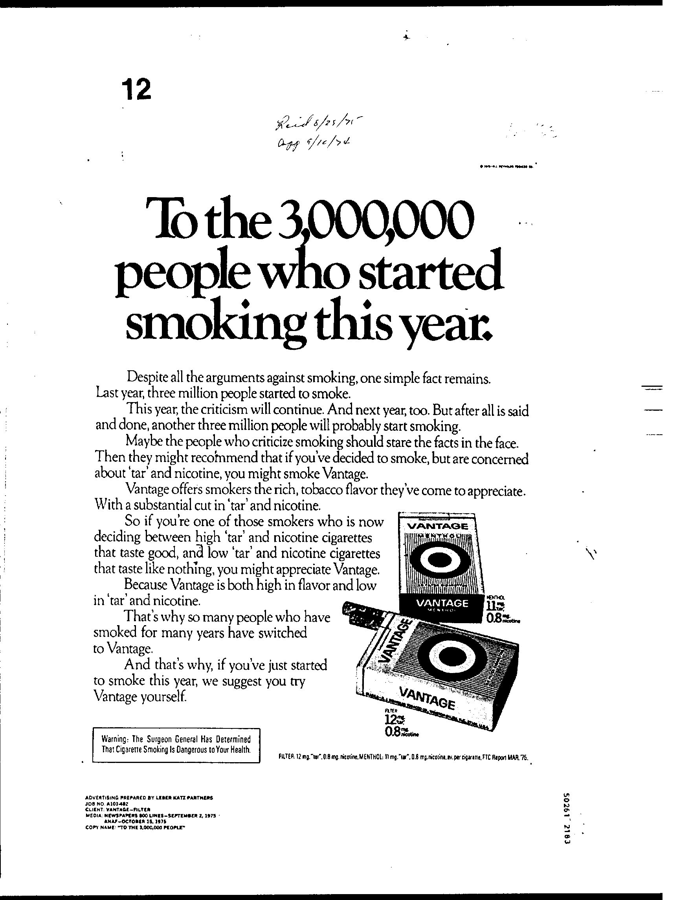

**Texto extraido**

12
| Red sfas/n-
Ogg tfiefod

Oe as. preeenon mend

To the 3,000,000
people who st started
smoking this year.

Despite all the arguments against smoking, one simple fact remains.
Last year, three million people started to smoke.

This year, the criticism will continue. And next year, too. Butafter all is said
and done, another three million people will probably start smoking.

Maybe the people who criticize smoking should stare the facts in the face.
Then they might recommend that if you've decided to smoke, but are concerned
about ‘tar’ and nicotine, you might smoke Vantage.

Vantage offers smokers the rich, tobacco flavor they've come to appreciate.
Witha substantial cut in ‘tar’ and nicotine.

So if you're one of those smokers who is now
deciding between high ‘tar’ and nicotine cigarettes
that taste good, and low tar’ and nicotine cigarettes
that taste like nothing, you might appreciate Vantage.

Because Vantage is both high in flavor and low
in ‘tar’ and nicotine.

That's why so ma

run_id                                                                         ocr-smoke-001-tesseract-none
tool                                                                                              tesseract
preset                                                                                                 none
category                                                                                               ADVE
input_path                                                        data/raw/dataset/ADVE/502612183+-2183.jpg
status                                                                                              success
elapsed_seconds                                                                                    4.873455
text_length                                                                                            1606
word_count                                                                                              261
confidence_avg              

In [8]:
# Exemplo: primeiro resultado real do Tesseract.
# Altere tool/preset/run_id/index para navegar por outros resultados.
review_result(tool="tesseract", preset="none", status="success")

## 5. Comparar OCRs no mesmo documento

Esta visao ajuda a responder: para a mesma imagem, qual ferramenta extraiu o texto mais util?

### Documento comparado: `data/raw/dataset/ADVE/502612183+-2183.jpg`

**Imagem original**  
`data\raw\dataset\ADVE\502612183+-2183.jpg`  
Original: `1728x2292` | Preview: `679x900`

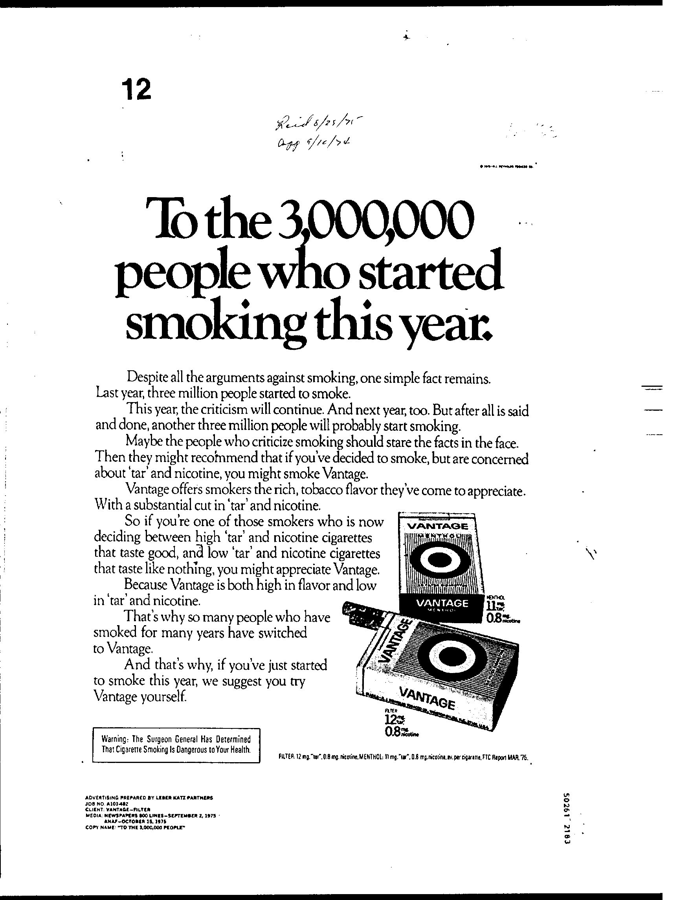

,run_id,tool,preset,elapsed_seconds,text_length,word_count,preview
0,ocr-smoke-dev-doctr-basic-no-weights-single-thread,doctr,basic,10.993475,2,1,#ë
1,ocr-smoke-001-doctr-none,doctr,none,21.439833,1502,239,"4 12 Reidsfs/ app s/ie/7c Tothe 3,000,000 people who started smoking this year Despite all the arguments against smoking, one simple fac..."
2,ocr-smoke-dev-doctr-none-pretrained-2,doctr,none,20.469273,1502,239,"4 12 Reidsfs/ app s/ie/7c Tothe 3,000,000 people who started smoking this year Despite all the arguments against smoking, one simple fac..."
3,ocr-smoke-001-paddleocr-none,paddleocr,none,28.644099,1109,159,"12 8/25 atg 1/> To the 3,000,000 people who started smoking this year. Despite all the arguments against smoking, one simple fact remain..."
4,ocr-smoke-dev-paddleocr-v4-none,paddleocr,none,51.659296,1109,159,"12 8/25 atg 1/> To the 3,000,000 people who started smoking this year. Despite all the arguments against smoking, one simple fact remain..."
5,ocr-smoke-001-tesseract-none,tesseract,none,4.873455,1606,261,"12 | Red sfas/n- Ogg tfiefod Oe as. preeenon mend To the 3,000,000 people who st started smoking this year. Despite all the arguments ag..."
6,ocr-smoke-dev-tesseract-none-installed,tesseract,none,2.460369,1606,261,"12 | Red sfas/n- Ogg tfiefod Oe as. preeenon mend To the 3,000,000 people who st started smoking this year. Despite all the arguments ag..."


#### doctr / basic / ocr-smoke-dev-doctr-basic-no-weights-single-thread

#ë


#### doctr / none / ocr-smoke-001-doctr-none

4
12
Reidsfs/
app s/ie/7c
Tothe 3,000,000
people who started
smoking this year
Despite all the arguments against smoking, one simple fact remains.
Last year, three million people started to smoke.
This year, the criticism will continue. And next year, too. Butafter all is said
and done,another three million people will probably start smoking.
Maybe the people who criticize smoking should stare the facts in the face.
Then they might recommend that if you ve decided to smoke, but are concerned
about 'tar' and nicotine, you might smoke Vantage.
Vantage offers smokers the rich, tobacco flavor they've come to appreciate.
With a substantial cut in tar and nicotine.
So if you're one of those smokers who is now VANTAGE
deciding between high 'tar' and nicotine cigarettes
that taste good, and low tar' and nicotine cigarettes
that taste like nothing, you might appreciate Vantage.
Because Vantage is both high in flavor and low
in tar' and nicotine.
VANTAGE HENTOL 112
That'swhy SO many people who h

...

#### tesseract / none / ocr-smoke-001-tesseract-none

12
| Red sfas/n-
Ogg tfiefod

Oe as. preeenon mend

To the 3,000,000
people who st started
smoking this year.

Despite all the arguments against smoking, one simple fact remains.
Last year, three million people started to smoke.

This year, the criticism will continue. And next year, too. Butafter all is said
and done, another three million people will probably start smoking.

Maybe the people who criticize smoking should stare the facts in the face.
Then they might recommend that if you've decided to smoke, but are concerned
about ‘tar’ and nicotine, you might smoke Vantage.

Vantage offers smokers the rich, tobacco flavor they've come to appreciate.
Witha substantial cut in ‘tar’ and nicotine.

So if you're one of those smokers who is now
deciding between high ‘tar’ and nicotine cigarettes
that taste good, and low tar’ and nicotine cigarettes
that taste like nothing, you might appreciate Vantage.

Because Vantage is both high in flavor and low
in ‘tar’ and nicotine.

That's why so ma

#### tesseract / none / ocr-smoke-dev-tesseract-none-installed

12
| Red sfas/n-
Ogg tfiefod

Oe as. preeenon mend

To the 3,000,000
people who st started
smoking this year.

Despite all the arguments against smoking, one simple fact remains.
Last year, three million people started to smoke.

This year, the criticism will continue. And next year, too. Butafter all is said
and done, another three million people will probably start smoking.

Maybe the people who criticize smoking should stare the facts in the face.
Then they might recommend that if you've decided to smoke, but are concerned
about ‘tar’ and nicotine, you might smoke Vantage.

Vantage offers smokers the rich, tobacco flavor they've come to appreciate.
Witha substantial cut in ‘tar’ and nicotine.

So if you're one of those smokers who is now
deciding between high ‘tar’ and nicotine cigarettes
that taste good, and low tar’ and nicotine cigarettes
that taste like nothing, you might appreciate Vantage.

Because Vantage is both high in flavor and low
in ‘tar’ and nicotine.

That's why so ma

,run_id,tool,preset,elapsed_seconds,text_length,word_count,preview
0,ocr-smoke-dev-doctr-basic-no-weights-single-thread,doctr,basic,10.993475,2,1,#ë
1,ocr-smoke-001-doctr-none,doctr,none,21.439833,1502,239,"4 12 Reidsfs/ app s/ie/7c Tothe 3,000,000 people who started smoking this year Despite all the arguments against smoking, one simple fac..."
2,ocr-smoke-dev-doctr-none-pretrained-2,doctr,none,20.469273,1502,239,"4 12 Reidsfs/ app s/ie/7c Tothe 3,000,000 people who started smoking this year Despite all the arguments against smoking, one simple fac..."
3,ocr-smoke-001-paddleocr-none,paddleocr,none,28.644099,1109,159,"12 8/25 atg 1/> To the 3,000,000 people who started smoking this year. Despite all the arguments against smoking, one simple fact remain..."
4,ocr-smoke-dev-paddleocr-v4-none,paddleocr,none,51.659296,1109,159,"12 8/25 atg 1/> To the 3,000,000 people who started smoking this year. Despite all the arguments against smoking, one simple fact remain..."
5,ocr-smoke-001-tesseract-none,tesseract,none,4.873455,1606,261,"12 | Red sfas/n- Ogg tfiefod Oe as. preeenon mend To the 3,000,000 people who st started smoking this year. Despite all the arguments ag..."
6,ocr-smoke-dev-tesseract-none-installed,tesseract,none,2.460369,1606,261,"12 | Red sfas/n- Ogg tfiefod Oe as. preeenon mend To the 3,000,000 people who st started smoking this year. Despite all the arguments ag..."


In [9]:
def compare_document(input_path=None, category=None, status="success", max_chars=1800):
    dataset = active_results()
    if dataset.empty:
        display(Markdown("Sem resultados carregados."))
        return pd.DataFrame()

    candidates = filter_results(category=category, status=status)
    if candidates.empty:
        display(Markdown("Nenhum candidato encontrado para comparacao."))
        return pd.DataFrame()

    if input_path is None:
        input_path = candidates.iloc[0]["input_path"]

    same_doc = filter_results(input_path=input_path, status=status).sort_values(["tool", "preset", "run_id"])
    if same_doc.empty:
        display(Markdown(f"Nenhum resultado encontrado para `{input_path}`."))
        return pd.DataFrame()

    display(Markdown(f"### Documento comparado: `{input_path}`"))
    display_image(input_path, "Imagem original")

    overview_rows = []
    payloads = []
    for _, row in same_doc.iterrows():
        payload = load_result_json(row)
        text = payload.get("text", "") or ""
        payloads.append((row, text))
        overview_rows.append(
            {
                "run_id": row["run_id"],
                "tool": row["tool"],
                "preset": row["preset"],
                "elapsed_seconds": row.get("elapsed_seconds"),
                "text_length": row.get("text_length"),
                "word_count": row.get("word_count"),
                "preview": " ".join(text.split())[:220],
            }
        )

    overview = pd.DataFrame(overview_rows)
    display(overview)

    for row, text in payloads:
        display(Markdown(f"#### {row['tool']} / {row['preset']} / {row['run_id']}"))
        print(text[:max_chars])
        if len(text) > max_chars:
            print(f"\n... texto truncado no preview ({len(text)} caracteres no total)")

    return overview


compare_document()

## 6. Rascunho de avaliacao humana

Depois de revisar visualmente, use uma coluna simples para marcar qualidade: `good`, `partial`, `bad` ou `failed`.

Isto vira uma metrica humana inicial para comparar ferramentas antes de criarmos um gabarito formal.

In [10]:
def build_human_review_template(status="success"):
    dataset = active_results()
    if dataset.empty:
        return pd.DataFrame()

    columns = [
        "run_id",
        "tool",
        "preset",
        "category",
        "input_path",
        "status",
        "elapsed_seconds",
        "text_length",
        "word_count",
    ]
    review = filter_results(status=status)[[column for column in columns if column in dataset.columns]].copy()
    review["human_score"] = ""
    review["human_notes"] = ""
    return review


human_review = build_human_review_template()
display(human_review)


def save_human_review(review_df, filename="documentation/reports/ocr-human-review-draft.csv"):
    output_path = ROOT / filename
    output_path.parent.mkdir(parents=True, exist_ok=True)
    review_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")


# Quando preencher human_score/human_notes, rode:
# save_human_review(human_review)

,run_id,tool,preset,category,input_path,status,elapsed_seconds,text_length,word_count,human_score,human_notes
0,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,21.439833,1502,239,,
1,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/2084396137_6138.jpg,success,2.457794,229,32,,
2,ocr-smoke-001-doctr-none,doctr,none,ADVE,data/raw/dataset/ADVE/2050834062.jpg,success,1.831152,40,15,,
3,ocr-smoke-001-doctr-none,doctr,none,Email,data/raw/dataset/Email/2078309558.jpg,success,5.246307,1142,184,,
4,ocr-smoke-001-doctr-none,doctr,none,Email,data/raw/dataset/Email/529216154+-6154.jpg,success,3.305349,624,89,,
...,...,...,...,...,...,...,...,...,...,...,...
89,ocr-smoke-001-tesseract-none,tesseract,none,Scientific,data/raw/dataset/Scientific/50085955_50085963.jpg,success,1.781222,1587,275,,
90,ocr-smoke-dev-doctr-basic-no-weights-single-thread,doctr,basic,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,10.993475,2,1,,
91,ocr-smoke-dev-doctr-none-pretrained-2,doctr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,20.469273,1502,239,,
92,ocr-smoke-dev-paddleocr-v4-none,paddleocr,none,ADVE,data/raw/dataset/ADVE/502612183+-2183.jpg,success,51.659296,1109,159,,
